In [1]:
import sys
from pathlib import Path

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]
PyTorch: 2.13.0+cpu
CUDA available: False


In [2]:
MODEL_NAME = "google/siglip-base-patch16-224"

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

TEST_FILE = PROCESSED_DIR / "test.csv"

print("Model:", MODEL_NAME)
print("Test data:", TEST_FILE)

Model: google/siglip-base-patch16-224
Test data: C:\Documents\GeoSigLIP\data\processed\test.csv


In [3]:
test_df = pd.read_csv(TEST_FILE)

print("Test images:", len(test_df))
print("\nClass distribution:")
print(test_df["label"].value_counts().sort_index())

Test images: 1750

Class distribution:
label
Basalt             250
Granite            250
Gray siltstone     250
Light sandstone    250
Marble             250
Mudstone           250
Red sandstone      250
Name: count, dtype: int64


In [4]:
%pip install -U sentencepiece

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

processor = AutoProcessor.from_pretrained(
    MODEL_NAME
)

model = AutoModelForZeroShotImageClassification.from_pretrained(
    MODEL_NAME
)

model = model.to(device)
model.eval()

print("Model loaded.")

Using device: cpu


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


spiece.model: reconstructing file:   0%|          |  0.00B /  798kB            

spiece.model: downloading bytes:           |  0.00B            

C:\Users\utkar\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\utkar\.cache\huggingface\hub\models--google--siglip-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


...

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  813MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Model loaded.


In [6]:
class_names = sorted(
    test_df["label"].unique()
)

prompts = [
    f"a drill core image of {label}"
    for label in class_names
]

for label, prompt in zip(class_names, prompts):
    print(label, "→", prompt)

Basalt → a drill core image of Basalt
Granite → a drill core image of Granite
Gray siltstone → a drill core image of Gray siltstone
Light sandstone → a drill core image of Light sandstone
Marble → a drill core image of Marble
Mudstone → a drill core image of Mudstone
Red sandstone → a drill core image of Red sandstone


In [7]:
sample = test_df.iloc[0]

image = Image.open(
    sample["image_path"]
).convert("RGB")

inputs = processor(
    text=prompts,
    images=image,
    padding="max_length",
    return_tensors="pt"
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits_per_image

probabilities = torch.sigmoid(logits)[0]

prediction_index = probabilities.argmax().item()

print("Actual:", sample["label"])
print("Predicted:", class_names[prediction_index])

print("\nScores:")

for label, score in zip(
    class_names,
    probabilities.cpu().numpy()
):
    print(f"{label}: {score:.4f}")

Actual: Red sandstone
Predicted: Granite

Scores:
Basalt: 0.0000
Granite: 0.0117
Gray siltstone: 0.0001
Light sandstone: 0.0012
Marble: 0.0003
Mudstone: 0.0002
Red sandstone: 0.0024


In [8]:
def predict_image(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    inputs = processor(
        text=prompts,
        images=image,
        padding="max_length",
        return_tensors="pt"
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    scores = torch.sigmoid(
        outputs.logits_per_image
    )[0]

    prediction_index = scores.argmax().item()

    return (
        class_names[prediction_index],
        scores.cpu().numpy()
    )

In [9]:
results = []

for _, row in test_df.head(50).iterrows():

    prediction, scores = predict_image(
        row["image_path"]
    )

    results.append({
        "image_path": row["image_path"],
        "actual": row["label"],
        "prediction": prediction
    })

results_df = pd.DataFrame(results)

print(results_df.head())

                                          image_path         actual  \
0  C:\Documents\GeoSigLIP\data\raw\DCID\DCID-512-...  Red sandstone   
1  C:\Documents\GeoSigLIP\data\raw\DCID\DCID-512-...  Red sandstone   
2  C:\Documents\GeoSigLIP\data\raw\DCID\DCID-512-...  Red sandstone   
3  C:\Documents\GeoSigLIP\data\raw\DCID\DCID-512-...  Red sandstone   
4  C:\Documents\GeoSigLIP\data\raw\DCID\DCID-512-...  Red sandstone   

      prediction  
0        Granite  
1        Granite  
2  Red sandstone  
3        Granite  
4        Granite  


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    results_df["actual"],
    results_df["prediction"]
)

print(
    f"Preliminary zero-shot accuracy: "
    f"{accuracy:.4f}"
)

Preliminary zero-shot accuracy: 0.2800


In [11]:
results = []

for i, row in test_df.iterrows():

    prediction, scores = predict_image(
        row["image_path"]
    )

    results.append({
        "image_path": row["image_path"],
        "actual": row["label"],
        "prediction": prediction
    })

    if (i + 1) % 100 == 0:
        print(
            f"Processed {i + 1}/{len(test_df)}"
        )

results_df = pd.DataFrame(results)

print("Completed:", len(results_df))

Processed 100/1750
Processed 200/1750
Processed 300/1750
Processed 400/1750
Processed 500/1750
Processed 600/1750
Processed 700/1750
Processed 800/1750
Processed 900/1750
Processed 1000/1750
Processed 1100/1750
Processed 1200/1750
Processed 1300/1750
Processed 1400/1750
Processed 1500/1750
Processed 1600/1750
Processed 1700/1750
Completed: 1750


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

accuracy = accuracy_score(
    results_df["actual"],
    results_df["prediction"]
)

precision, recall, f1, _ = precision_recall_fscore_support(
    results_df["actual"],
    results_df["prediction"],
    average="macro",
    zero_division=0
)

print("=" * 50)
print("ZERO-SHOT SIGLIP BASELINE")
print("=" * 50)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Macro F1:  {f1:.4f}")

ZERO-SHOT SIGLIP BASELINE
Accuracy:  0.4754
Precision: 0.4443
Recall:    0.4754
Macro F1:  0.3854


In [13]:
from sklearn.metrics import classification_report

print(
    classification_report(
        results_df["actual"],
        results_df["prediction"],
        zero_division=0
    )
)

                 precision    recall  f1-score   support

         Basalt       0.00      0.00      0.00       250
        Granite       0.33      0.95      0.49       250
 Gray siltstone       0.38      0.93      0.54       250
Light sandstone       0.87      0.92      0.89       250
         Marble       0.70      0.15      0.25       250
       Mudstone       0.00      0.00      0.00       250
  Red sandstone       0.82      0.38      0.52       250

       accuracy                           0.48      1750
      macro avg       0.44      0.48      0.39      1750
   weighted avg       0.44      0.48      0.39      1750



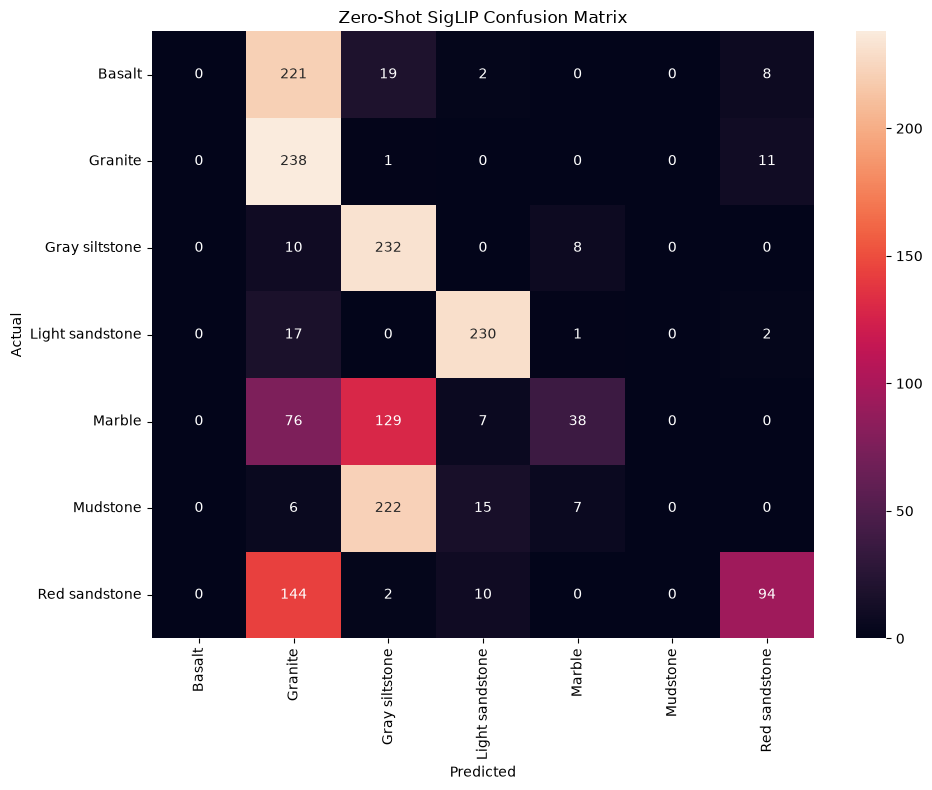

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    results_df["actual"],
    results_df["prediction"],
    labels=class_names
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Zero-Shot SigLIP Confusion Matrix")

plt.tight_layout()
plt.show()